# 🏠 MietCheck · 🧹 QUA³CK-Phase 1: Qualitätsprüfung

**Modul:** Data Analytics & Big Data (IU, 4. Semester) · **Projekt:** MietCheck – „Zahle ich zu viel Miete?"

> Teil 1 von 6 der QUA³CK-Notebook-Serie. Reihenfolge:
> **Q**ualitätsprüfung → **U**nderstanding → **A**lgorithmenauswahl →
> Modellentwicklung → **C**ross-Validation → **K**nowledge.

**Ziel:** aus den Rohdaten einen sauberen, vertrauenswürdigen Datensatz machen. Wir prüfen fehlende Werte und entfernen unplausible Ausreißer (Datenfehler), denn: *Garbage in, garbage out.*

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import config as C
sns.set_theme(style='whitegrid', palette='rocket')
print('Setup ok ·', ROOT.name)

Setup ok · MietCheck


## 1. Rohdaten laden

In [2]:
raw = pd.read_csv(C.RAW_CSV, low_memory=False)
print(f'Rohdaten: {raw.shape[0]:,} Zeilen × {raw.shape[1]} Spalten')
raw[[C.TARGET,'livingSpace','noRooms','regio1']].head()

Rohdaten: 268,850 Zeilen × 49 Spalten


,baseRent,livingSpace,noRooms,regio1
0,595.0,86.00,4.0,Nordrhein_Westfalen
1,800.0,89.00,3.0,Rheinland_Pfalz
2,965.0,83.80,3.0,Sachsen
3,343.0,58.15,3.0,Sachsen
4,765.0,84.97,3.0,Bremen


## 2. Fehlende Werte prüfen
Wie vollständig sind die für uns relevanten Merkmale?

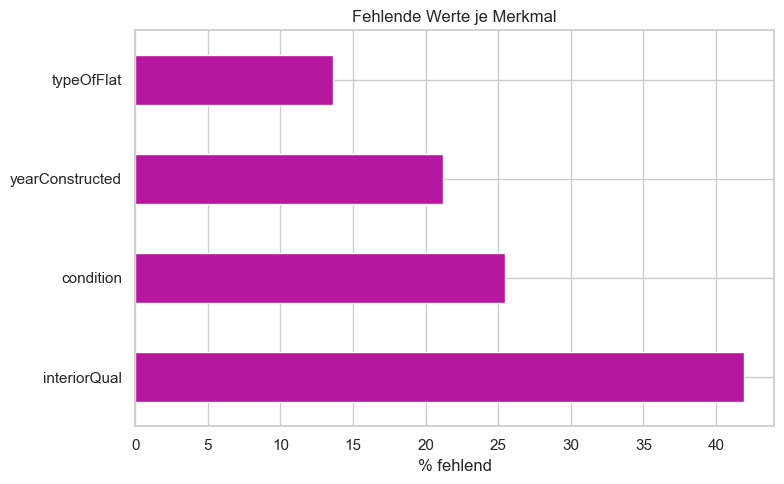

,fehlend_%
interiorQual,41.9
condition,25.5
yearConstructed,21.2
typeOfFlat,13.6
livingSpace,0.0
noRooms,0.0
regio1,0.0
regio2,0.0
balcony,0.0
hasKitchen,0.0


In [3]:
cols = [c for c in C.FEATURES + [C.TARGET] if c in raw.columns]
miss = (raw[cols].isna().mean()*100).round(1).sort_values(ascending=False)
ax = miss[miss>0].plot.barh(figsize=(8,5), color='#b5179e')
ax.set(title='Fehlende Werte je Merkmal', xlabel='% fehlend'); plt.tight_layout(); plt.show()
miss.to_frame('fehlend_%')

## 3. Unplausible Werte aufdecken
Die Zielgröße (Kaltmiete) enthält offensichtliche Datenfehler:

In [4]:
print('Kaltmiete roh – min/median/max:')
print(raw[C.TARGET].agg(['min','median','max']).round(0).to_string())
eur = (raw[C.TARGET]/raw['livingSpace']).replace([np.inf,-np.inf], np.nan)
print(f'\n€/m² roh – min {eur.min():.1f} | median {eur.median():.1f} | max {eur.max():.0f}')
print('=> Werte wie 0 € Miete oder >9 Mio. € sind Fehler und müssen raus.')

Kaltmiete roh – min/median/max:
min             0.0
median        490.0
max       9999999.0

€/m² roh – min 0.0 | median 7.4 | max 9999999
=> Werte wie 0 € Miete oder >9 Mio. € sind Fehler und müssen raus.


## 4. Plausibilitätsgrenzen anwenden
Wir nutzen exakt dieselbe Logik wie `src/data_prep.py` (damit Notebook und Pipeline konsistent bleiben).

In [5]:
for k,(lo,hi) in C.LIMITS.items():
    print(f'  {k:16} erlaubt: {lo} … {hi}')

  baseRent         erlaubt: 100 … 6000
  livingSpace      erlaubt: 15 … 300
  noRooms          erlaubt: 1 … 8
  yearConstructed  erlaubt: 1900 … 2025
  eur_per_sqm      erlaubt: 3 … 40


In [6]:
from data_prep import quality_check
clean = quality_check(raw)
print(f'\nBereinigt: {len(clean):,} Zeilen ({(1-len(clean)/len(raw))*100:.1f} % entfernt)')

→ Qualitaetspruefung: 268,850 → 202,908 Zeilen (24.5 % entfernt)

Bereinigt: 202,908 Zeilen (24.5 % entfernt)


## 5. Vorher / Nachher
Die Bereinigung entfernt die extremen Ausreißer sichtbar:

In [7]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
sns.boxplot(x=raw[C.TARGET].clip(upper=raw[C.TARGET].quantile(0.999)), ax=ax[0], color='#f85149')
ax[0].set(title='Kaltmiete VOR Bereinigung', xlabel='€')
sns.boxplot(x=clean[C.TARGET], ax=ax[1], color='#10b981')
ax[1].set(title='Kaltmiete NACH Bereinigung', xlabel='€')
plt.tight_layout(); plt.show()

## ✅ Fazit Phase Q
- Aus **268.850** wurden **202.908** saubere Angebote (~24,5 % entfernt).
- Entfernt wurden: fehlende Zielwerte, unplausible Mieten/Flächen und extreme €/m²-Ausreißer.
- Dieser bereinigte Datensatz (`data/immo_clean.parquet`) ist die Basis für **alle** folgenden Phasen.

➡️ Weiter mit **02 · Understanding the Data**.